In [27]:
import pandas as pd

# Data read

train_df = pd.read_csv('../data/train.csv')
test_df = pd.read_csv('../data/test.csv')

# check rows and columns
print(f"Train data shape: {train_df.shape}")
print(f"Test data shape: {test_df.shape}")

train_df.head()

Train data shape: (891, 12)
Test data shape: (418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [28]:
# Data summary
print(train_df.info())

# සංඛ්‍යාත්මක දත්තවල (Age, Fare) සාරාංශයක් බලමු
train_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


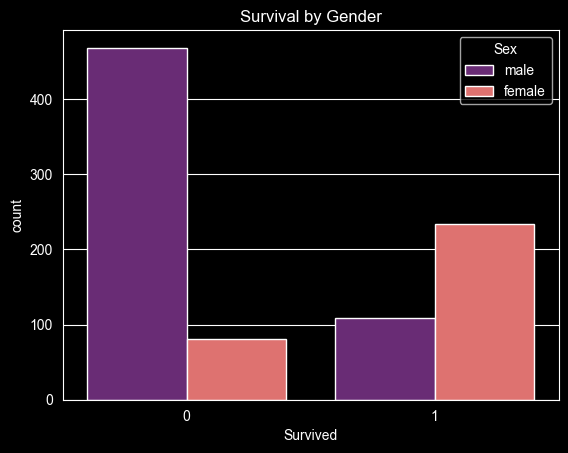

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

# ස්ත්‍රී/පුරුෂ භාවය අනුව බේරුණු ප්‍රමාණය බලමු
sns.countplot(x='Survived', hue='Sex', data=train_df, palette='magma')
plt.title('Survival by Gender')
plt.show()

මෙහිදී ඔයාට පෙනෙයි පිරිමි අයට වඩා කාන්තාවන් බේරීමේ සම්භාවිතාව ගොඩක් වැඩි බව. මේ වගේ තීක්ෂණ බුද්ධියක් (Insights) ලබාගන්න එක තමයි EDA වල ප්‍රධාන අරමුණ.

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


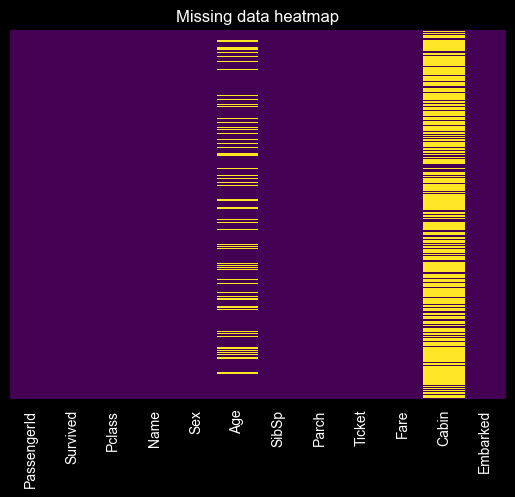

In [30]:
# හැම තීරුවකම තියෙන හිස් අගයන් ගණන බලමු
print(train_df.isnull().sum())

# Heatmap එකක් ඇඳලා බලමු (Visual representation)
sns.heatmap(train_df.isnull(),yticklabels=False, cbar=False, cmap='viridis')
plt.title('Missing data heatmap')
plt.show()

## Dropping Columns

- මචන්, හැම දත්තයක්ම මොඩලයකට වැදගත් වෙන්නේ නැහැ. උදාහරණයක් විදිහට, මගියෙකුගේ නම (Name) හෝ ටිකට් අංකය (Ticket) ඔහු බේරෙනවාද නැද්ද කියන එකට බලපාන්නේ නැහැ. ඒ වගේම Cabin තීරුවේ 77% ක්ම තියෙන්නේ හිස් තැන් (Missing values). ඒ නිසා අපි ඒවා අයින් කරමු.

In [31]:
train_df.drop(['Name','Ticket','Cabin','PassengerId'], axis=1, inplace=True)
train_df.head(10)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S
5,0,3,male,NaN,0,0,8.4583,Q
6,0,1,male,54.0,0,0,51.8625,S
7,0,3,male,2.0,3,1,21.0750,S
8,1,3,female,27.0,0,2,11.1333,S
9,1,2,female,14.0,1,0,30.0708,C


### Sklearn SimpleImputer පාවිච්චි කරමු

In [32]:
# අපි Age වල තියෙන හිස් තැන් ඒකේ මධ්‍යස්ථයෙන් (Median) පුරවමු.
from sklearn.impute import SimpleImputer

# Imputer එක හදාගමු (අපි පාවිච්චි කරන්නේ Median එක)
imputer = SimpleImputer(strategy='median')

# Age තීරුවට විතරක් මේක apply කරමු
# (Sklearn වලට 2D array එකක් ඕන නිසා [['Age']] ලෙස දෙන්න)
train_df['Age'] = imputer.fit_transform(train_df[['Age']])

train_df.isnull().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    2
dtype: int64

## අකුරු ඉලක්කම් කරමු (Categorical Encoding)

- මචන්, ML මොඩලයකට "Male" හෝ "Female" කියන වචන තේරෙන්නේ නැහැ. ඒවට දෙන්න ඕනේ 0 සහ 1 වගේ ඉලක්කම්. මේකට අපි Sklearn වල තියෙන LabelEncoder පාවිච්චි කරනවා.

In [37]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Sex තීරුව ඉලක්කම් වලට හරවමු (Male=1, Female=0 වගේ)
train_df['Sex'] = le.fit_transform(train_df['Sex'])

# Embarked (ගොඩවුණු වරාය) වලත් හිස් තැන් 2ක් තියෙනවා, ඒකත් ඉලක්කම් කරමු
train_df['Embarked'] = le.fit_transform(train_df['Embarked'].astype(str))

train_df.head(10)


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,2
1,1,1,0,38.0,1,0,71.2833,0
2,1,3,0,26.0,0,0,7.9250,2
3,1,1,0,35.0,1,0,53.1000,2
4,0,3,1,35.0,0,0,8.0500,2
5,0,3,1,28.0,0,0,8.4583,1
6,0,1,1,54.0,0,0,51.8625,2
7,0,3,1,2.0,3,1,21.0750,2
8,1,3,0,27.0,0,2,11.1333,2
9,1,2,0,14.0,1,0,30.0708,0


In [38]:
# පිරිසිදු කළ දත්ත 'data' folder එක ඇතුළේ save කරමු
train_df.to_csv('../data/train_cleaned.csv', index=False)

print("Cleaned data saved successfully! ✅")

Cleaned data saved successfully! ✅


### පියවර 01: Features සහ Labels වෙන් කරමු
මචන්, මුලින්ම අපි කරන්න ඕනේ අපේ දත්ත පද්ධතිය කොටස් දෙකකට බෙදන එක:

1.  Features (X): අපි අනාවැකිය කීමට භාවිතා කරන දත්ත (Pclass, Sex, Age, etc.).

2. Label (y): අපි අනාවැකිය කිව යුතු දේ (Survived).

In [39]:
# 'Survived' තීරුව ඉවත් කර අනෙක් සියල්ල Features (X) ලෙස ගනිමු
features = train_df.drop('Survived', axis=1)

# 'Survived' තීරුව පමණක් Label (y) ලෙස ගනිමු
labels = train_df['Survived']

### පියවර 02: දත්ත බෙදීම (Train/Validation/Test Split)
දැන් අපි මේ දත්ත ටික කොටස් 3කට බෙදන්න ඕනේ. මතකද අපි කලින් ඉගෙන ගත්තා:

- Training Set (60%): මොඩලයට ඉගෙන ගැනීමට.

- Validation Set (20%): මොඩලය ටියුන් (Tune) කරන්න සහ හොඳම එක තෝරන්න.

- Test Set (20%): අවසානයේ මොඩලය කොච්චර දක්ෂද කියලා බලන්න.

In [40]:
# Sklearn වල තියෙන train_test_split පාවිච්චි කරලා මේක ලේසියෙන්ම කරන්න පුළුවන්:

from sklearn.model_selection import train_test_split
# මුලින්ම 60% ක් training වලටත් ඉතිරි 40% පරීක්ෂණ වලටත් වෙන් කරමු

X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size=0.4, random_state=42)

# අර 40% න් භාගයක් (ඒ කියන්නේ මුළු දත්ත වලින් 20% ක්) Validation සඳහා වෙන් කරමු

X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, test_size=0.5, random_state=42)

# දැන් අපේ දත්ත බෙදී ඇති ආකාරය බලමු
print(f"Train: {len(y_train)} | Val: {len(y_val)} | Test: {len(y_test)}")


Train: 534 | Val: 178 | Test: 179
